In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("india_weather_rainfall_data.csv")

In [8]:
df.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='str')

In [9]:
df.shape

(970339, 15)

In [10]:
df.head()

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02 00:00:00,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.05,74.4,0.1
1,2021-01-03 00:00:00,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.05,74.4,4.4
2,2021-01-04 00:00:00,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.05,74.4,2.3
3,2021-01-05 00:00:00,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.05,74.4,35.0
4,2021-01-06 00:00:00,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.05,74.4,25.5


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 970339 entries, 0 to 970338
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date_of_record  970339 non-null  str    
 1   month           970339 non-null  str    
 2   season          970339 non-null  str    
 3   station_name    970339 non-null  str    
 4   state           970339 non-null  str    
 5   district        970339 non-null  str    
 6   avg_temp        970339 non-null  float64
 7   min_temp        926441 non-null  float64
 8   max_temp        859741 non-null  float64
 9   wind_speed      695895 non-null  float64
 10  air_pressure    665675 non-null  float64
 11  elevation       970339 non-null  int64  
 12  latitude        970339 non-null  float64
 13  longitude       970339 non-null  float64
 14  rainfall        712785 non-null  float64
dtypes: float64(8), int64(1), str(6)
memory usage: 161.2 MB


In [12]:
df.isnull().sum()

date_of_record         0
month                  0
season                 0
station_name           0
state                  0
district               0
avg_temp               0
min_temp           43898
max_temp          110598
wind_speed        274444
air_pressure      304664
elevation              0
latitude               0
longitude              0
rainfall          257554
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
count,970339.000000,926441.000000,859741.000000,695895.000000,665675.000000,970339.000000,970339.000000,970339.000000,712785.000000
mean,25.661709,20.647342,31.195383,9.432732,1009.437663,298.181018,20.793670,79.426826,5.267533
std,5.438133,6.008171,5.464499,4.979263,5.292871,415.266215,6.328275,5.852512,14.444142
min,-10.400000,-18.500000,-5.600000,0.000000,922.600000,0.000000,7.983300,68.850000,0.000000
25%,23.100000,17.100000,28.500000,6.100000,1005.800000,16.000000,15.850000,75.400000,0.000000
50%,26.700000,22.400000,31.600000,8.400000,1009.800000,139.000000,21.616700,78.066700,0.000000
75%,29.100000,25.000000,34.400000,11.600000,1013.300000,436.000000,25.566700,82.716700,4.000000
max,43.400000,36.600000,87.000000,66.600000,1036.500000,2652.000000,34.083300,95.383300,485.900000


In [15]:
df.drop_duplicates()
df.shape

(970339, 15)

In [16]:
df["date_of_record"] = pd.to_datetime(df["date_of_record"])
df["year"] = df["date_of_record"].dt.year
df["month"] = df["date_of_record"].dt.month
df["day"] = df["date_of_record"].dt.day

In [17]:
numeric_cols =df.select_dtypes(include=np.number).columns
for col in numeric_cols:df[col]= df[col].fillna(df[col].median)

categorical_cols= df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].notna().any():
      df[col]=df[col].fillna(df[col].mode()[0])

print("Missing values remaining:")
df.isnull().sum()

C:\Users\edune\AppData\Local\Temp\ipykernel_17752\2829216450.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols= df.select_dtypes(include='object').columns


Missing values remaining:


date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
year              0
day               0
dtype: int64

In [18]:
#Rainfall Target creation

df['rainfall']=pd.to_numeric(df['rainfall'],errors='coerce')
df['Rain_Today'] = (df['rainfall'] >= 2.5).astype(int)
df['Rain_Today'].value_counts()

Rain_Today
0    762176
1    208163
Name: count, dtype: int64

In [19]:
#Sorting

df = df.sort_values(['station_name','date_of_record'])
df['Rainfall_Tommorow'] = df.groupby('station_name')['rainfall'].shift(-1)
df['Rainfall_Tommorow']=(df['Rainfall_Tommorow'] >= 2.5).astype(int)
df = df.dropna(subset=['Rainfall_Tommorow'])


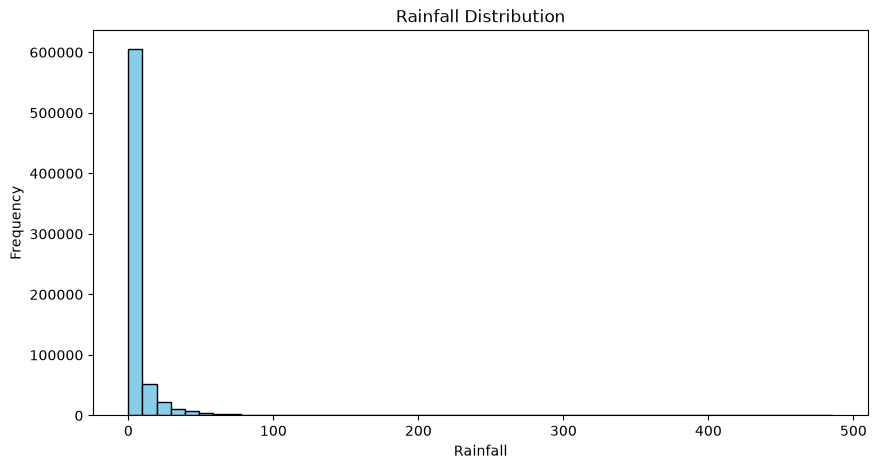

In [20]:
#Exploratory Data Analysis

#Rainfall Distribution

plt.figure(figsize=(10, 5))
plt.hist(df['rainfall'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')
plt.title('Rainfall Distribution')
plt.show()

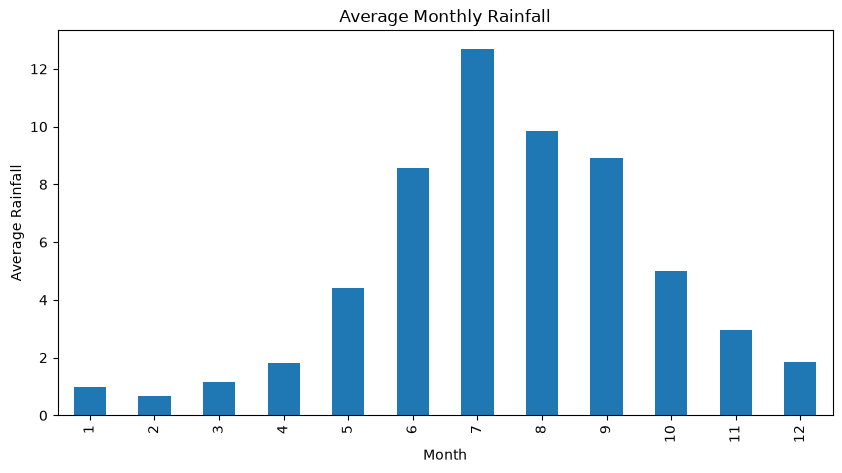

In [21]:
# Monthly Rainfall

monthly = df.groupby('month')['rainfall'].mean()

plt.figure(figsize=(10, 5))
monthly.plot(kind='bar')
plt.title('Average Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Average Rainfall')
plt.show()

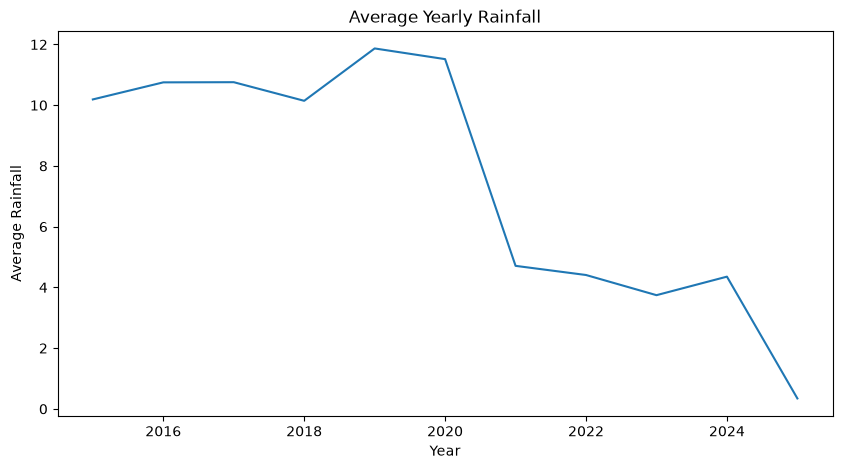

In [22]:
#Yearly Rainfall

yearly = df.groupby('year')['rainfall'].mean()

plt.figure(figsize=(10, 5))
yearly.plot(kind='line')
plt.title('Average Yearly Rainfall')
plt.xlabel('Year')
plt.ylabel('Average Rainfall')
plt.show()

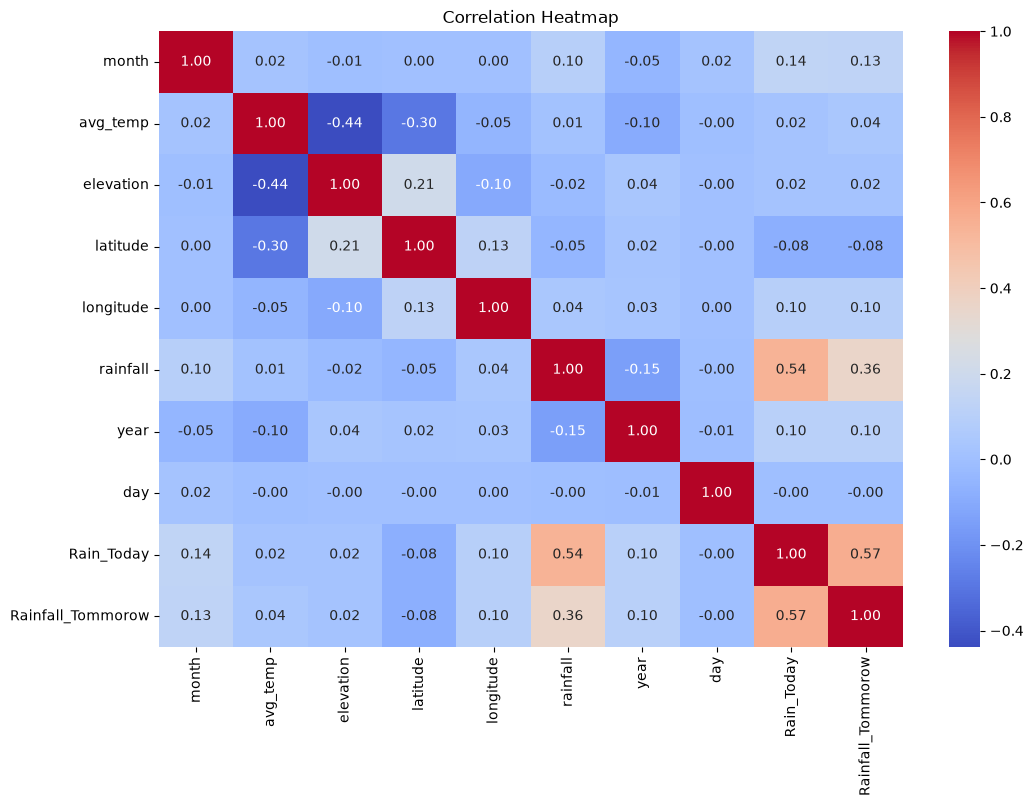

In [23]:
#Correlation

plt.figure(figsize=(12,8))

numeric_df =df.select_dtypes(include=np.number)
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=True,
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

In [24]:
features=[
    'avg_temp',
    'min_temp',
    'max_temp',
    'wind_speed',
    'air_pressure',
    'latitude',
    'longitude',
    'elevation',
    'month'
]

In [25]:
#Train-test-Split

train = df[df['year']< 2024]
test = df[df['year'] >= 2024]

X_train = train[features]
y_train = train['Rainfall_Tommorow']

X_test = test[features]
y_test = test['Rainfall_Tommorow']

print("Training:",X_train.shape,y_train.shape)
print("Testing:",X_test.shape,y_test.shape)

Training: (805740, 9) (805740,)
Testing: (164599, 9) (164599,)


In [28]:
print(X_train.dtypes)
X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

avg_temp        float64
min_temp         object
max_temp         object
wind_speed       object
air_pressure     object
latitude        float64
longitude       float64
elevation         int64
month             int32
dtype: object


In [29]:
#Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_scaled,
    y_train
)

y_pred = model.predict(X_test_scaled)


In [31]:
#Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred,zero_division=0)
recall = recall_score(y_test, y_pred,zero_division=0)
f1 = f1_score(y_test, y_pred,zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred,zero_division=0))

Accuracy: 0.7628964939033651
Precision: 0.5095419847328244
Recall: 0.006839664933268438
F1 Score: 0.013498142109653447

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.87    125562
           1       0.51      0.01      0.01     39037

    accuracy                           0.76    164599
   macro avg       0.64      0.50      0.44    164599
weighted avg       0.70      0.76      0.66    164599



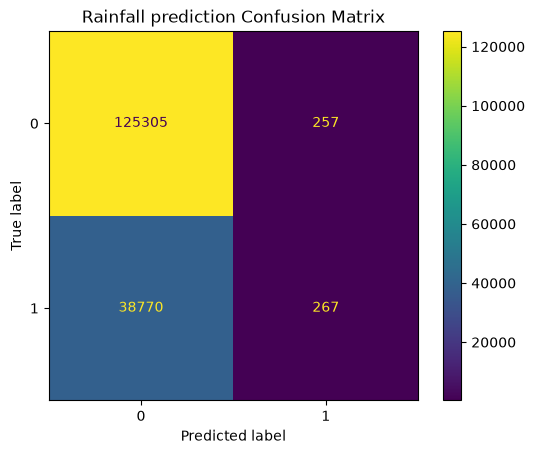

In [33]:
#Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title('Rainfall prediction Confusion Matrix')
plt.show()

In [32]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_pred=rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred,zero_division=0)
rf_recall = recall_score(y_test, rf_pred,zero_division=0)
rf_f1 = f1_score(y_test, rf_pred,zero_division=0)


print("Random Forest Results")
print("---------------------")
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1 Score:", rf_f1)

c:\Users\edune\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Random Forest Results
---------------------
Random Forest Accuracy: 0.7626960066586067
Random Forest Precision: 0.1891891891891892
Random Forest Recall: 0.000179317058175577
Random Forest F1 Score: 0.00035829451809387314


In [34]:
 #Model Comparison

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy],
    'Precision': [precision, rf_precision],
    'Recall': [recall, rf_recall],
    'F1 Score': [f1, rf_f1]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.762896,0.509542,0.006840,0.013498
1,Random Forest,0.762696,0.189189,0.000179,0.000358


In [35]:
import joblib
joblib.dump(model, 'rainfall_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully")

Model and scaler saved successfully
